# Single value deconvolution of replication timing

May 6, 2024

Goal: Can we deconvolve a single value (position in S/G2M) where replication occurs for each 10k window?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [447]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves()

mnase_analysis_rep2 = MNaseOriginAnalysis(replicate=2)
mnase_analysis_rep2.compute_bin_curves()


1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:23.917
1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:03.913


In [460]:
# Normalize data and compute raw data replicating timings
mnase_analysis_rep1.normalize_and_compute_raw_replication_timing()
mnase_analysis_rep2.normalize_and_compute_raw_replication_timing()

In [462]:
from src.stepwise_replication_solver import StepReplicationChromatinDeconvolveSolver
solver = StepReplicationChromatinDeconvolveSolver(mnase_analysis_rep1, mnase_analysis_rep2)

In [512]:
solver.deconvolve_chr_all_bins(10)

40/368 - 00:00:20.216
80/368 - 00:00:45.805
120/368 - 00:01:10.897
160/368 - 00:01:35.917
200/368 - 00:02:02.766
280/368 - 00:02:50.873
320/368 - 00:03:17.776
360/368 - 00:03:44.623


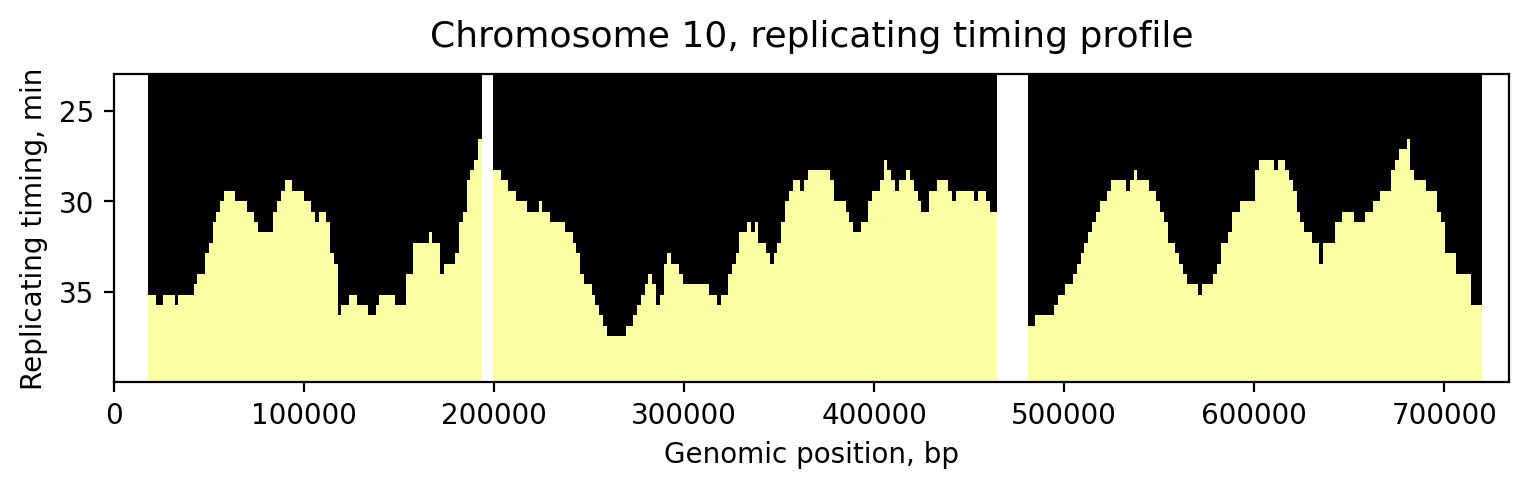

In [519]:
solver.plot_deconvolved_chrom_f()

In [532]:
solver.deconvolve_all_chromosomes()

Chromosome 1
0/111 - 00:00:00.666
40/111 - 00:00:27.059
done. - 00:01:02.242
Chromosome 2
40/402 - 00:00:23.230
80/402 - 00:00:50.155
120/402 - 00:01:15.339
160/402 - 00:01:38.466
200/402 - 00:02:06.585
240/402 - 00:02:33.438
280/402 - 00:02:59.918
320/402 - 00:03:27.729
360/402 - 00:03:53.686
400/402 - 00:04:20.608
done. - 00:05:24.517
Chromosome 3
0/154 - 00:00:00.659
80/154 - 00:00:45.870
120/154 - 00:01:12.775
done. - 00:06:58.697
Chromosome 4
40/761 - 00:00:21.706
80/761 - 00:00:48.756
120/761 - 00:01:15.253
160/761 - 00:01:41.527
200/761 - 00:02:09.117
240/761 - 00:02:37.172
280/761 - 00:02:57.633
360/761 - 00:03:46.545
400/761 - 00:04:13.329
480/761 - 00:05:01.362
520/761 - 00:05:24.270
560/761 - 00:05:47.308
640/761 - 00:06:36.844
680/761 - 00:07:03.226
720/761 - 00:07:29.013
done. - 00:14:56.999
Chromosome 5
40/284 - 00:00:25.813
80/284 - 00:00:54.085
120/284 - 00:01:20.448
160/284 - 00:01:47.245
200/284 - 00:02:14.431
240/284 - 00:02:37.488
280/284 - 00:03:00.062
done. - 00:1

In [534]:
solver.all_chrom_fs_df.to_csv('output/deconvolved_all_chr_replication_profile_delta_model.csv')

(175.0, 50.0)

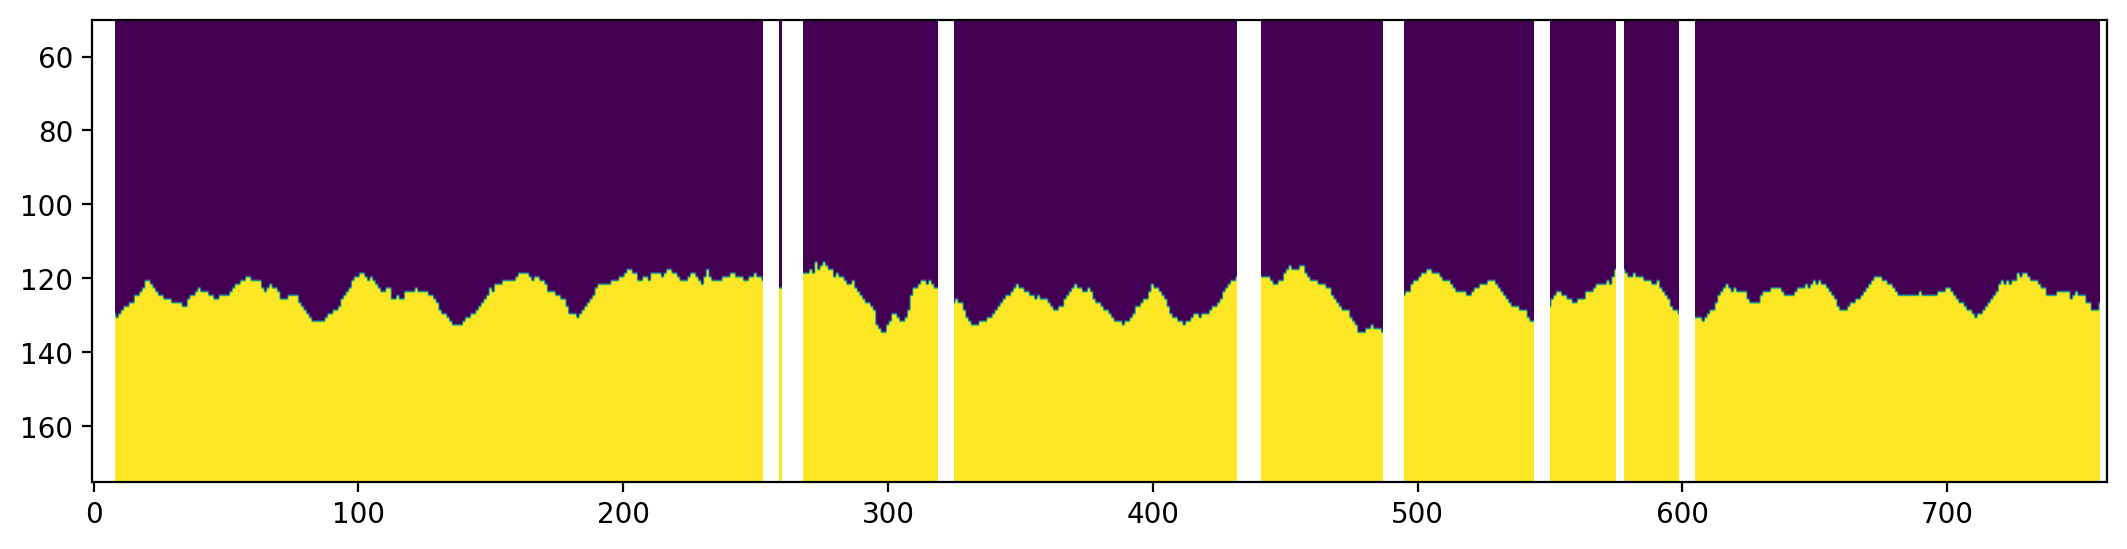

In [545]:
plt.figure(figsize=(13, 3))
plt.imshow(solver.all_chrom_fs_df.loc[4].T, aspect='auto')
plt.ylim(175, 50)